In [1]:
from chessrl import chess_py as cp
from chessrl.env import RandomDefender, SyzygyDefender, Env
from chessrl.utils.plot_chess import plot_game
from mcts import MCTS

import csv, torch, numpy as np, random
import pandas as pd
import torch, numpy as np

2025-09-01 19:42:46,651 - INFO - Loading config file...


In [2]:
def set_seed(s=0):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

def load_fens_from_csv(csv_path, limit=None):
    fens = []
    with open(csv_path, newline='') as f:
        r = csv.DictReader(f)
        for row in r:
            fen = row["fen"]
            # make sure it's White to move
            if " w " in fen.split(" ", 2)[1:2] or fen.split()[1] == 'w':
                fens.append(fen)
                if limit and len(fens) >= limit: break
    return fens
set_seed(0)
device = torch.device('cpu')

csv_path = "../../../../tablebase/krk/krk_train.csv"   # <-- point to your CSV (fen,side,wdl,dtz)
fens = load_fens_from_csv(csv_path, limit=5000)  # start with 50k WTM positions
df = pd.read_csv(csv_path)
fens = df[df['dtz'] == 1]['fen'].tolist()
fens[1]

'2R5/8/8/8/8/8/5K1k/8 w - - 0 1'

Best move: b1f1


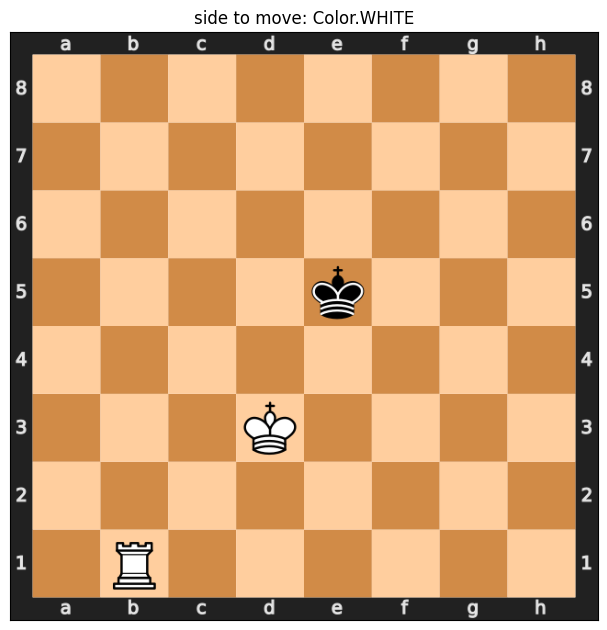

In [4]:
env = Env.from_fen(
    "8/8/8/4k3/8/3K4/8/1R6 w - - 0 1",
    defender=RandomDefender(0),
    absorb_black_reply=True
)

mcts = MCTS(seconds=10.0, iterations=5_000, use_env_in_rollout=True,
            defender=RandomDefender(0), absorb_black_reply=True)
best = mcts.search(env.state())

if best is not None:
    print("Best move:", cp.Move.to_uci(best))

env.display_state()
